This notebook take a time-series of Sentinel-2 scene at the specified location for a given year and shows different techniques for creating composites. The notebook shows how to create Median, Percentile and Geomedian composites and see its effect in removing effect of clouds and preserving relationship between spectral bands.

### Setup

Determine our runtime environment.

In [ ]:
import os

if 'COLAB_RELEASE_TAG' in os.environ:
    environment = 'colab'
    if os.environ.get('VERTEX_PRODUCT') == 'COLAB_ENTERPRISE':
        environment = 'colab_enterprise'
else:
    environment = 'local'

# Set to True to use Google Drive for data storage in Colab
use_google_drive = True

# Google Drive is available only in 'colab' environment
if environment == 'colab' and use_google_drive:
    from google.colab import drive
    drive.mount('/content/drive')
    drive_folder_root = 'MyDrive'
    drive_data_folder = 'python-remote-sensing'
    drive_folder_path = os.path.join('/content/drive', drive_folder_root, drive_data_folder)
    data_folder = drive_folder_path
    output_folder = drive_folder_path
else:
    data_folder = 'data'
    output_folder = 'output'

if not os.path.exists(data_folder):
    os.mkdir(data_folder)
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

print(f'Environment: {environment}')
print(f'Data folder: {data_folder}')
print(f'Output folder: {output_folder}')

If we are on Google Colab, install the required packages. Local runtimes are expected to have the packages already installed.

In [ ]:
%%capture
if environment in ['colab', 'colab_enterprise']:
    !pip install pystac-client odc-stac rioxarray \
        dask['distributed'] jupyter-server-proxy xrscipy odc-algo hdstats

Import all required libraries. Make sure to import everything at the beginning as certain Xarray extensions are activated on import and registers certain accesors, like `.rio` and `.odc` for Xarray objects.

In [ ]:
import dask
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import os
import pyproj
import pystac_client
import rioxarray as rxr
import xarray as xr
from odc.algo import xr_geomedian, xr_quantile
from odc.stac import configure_s3_access, load

Setup a local Dask cluster. This distributes the computation across multiple workers on your computer.

In [ ]:
from dask.distributed import Client
client = Client()  # set up local cluster on the machine
client

If you are running this notebook in Colab, you will need to create and use a proxy URL to see the dashboard running on the local server.

In [ ]:
if environment == 'colab':
    from google.colab import output
    port_to_expose = 8787  # This is the default port for Dask dashboard
    print(output.eval_js(f'google.colab.kernel.proxyPort({port_to_expose})'))

### Get Satellite Imagery using STAC API

We define a location and time of interest to get some satellite imagery.

In [ ]:
latitude = 27.163
longitude = 82.608
year = 2023

Let's use Element84 search endpoint to look for items from the sentinel-2-l2a collection on AWS and load the matching images as a XArray Dataset.

In [ ]:
# Define a GeoJSON geometry
geometry = {
    'type': 'Point',
    'coordinates': [longitude, latitude]
}

# Query the STAC Catalog
catalog = pystac_client.Client.open(
    'https://earth-search.aws.element84.com/v1')

search = catalog.search(
    collections=['sentinel-2-c1-l2a'],
    intersects=geometry,
    datetime=f'{year}',
    query={
        's2:nodata_pixel_percentage': {'lt': 10}
    }

)
items = search.item_collection()

# Load to XArray
ds = load(
    items,
    bands=['red', 'green', 'blue', 'scl'],
    resolution=100,
    crs='utm',
    chunks={'x': 1024, 'y': 1024},  # Explicitly define chunk sizes
    groupby='solar_day',
    preserve_original_order=True
)
ds

### Processing Data

We have a data cube of multiple scenes collected through the year. As XArray supports vectorized operations, we can work with the entire DataSet the same way we would process a single scene.

The Sentinel-2 scenes come with NoData value of 0. So we set the correct NoData value before further processing.

In [ ]:
# Mask nodata values
ds = ds.where(ds != 0)

Apply scale and offset to all spectral bands

In [ ]:
# Apply scale/offset
scale = 0.0001
offset = -0.1
# Select spectral bands (all except 'scl')
data_bands = [band for band in ds.data_vars if band != 'scl']
for band in data_bands:
  ds[band] = ds[band] * scale + offset

Check the size of the data cube.



In [ ]:
print(f'Data cube size: {ds.nbytes/1e6:.2f} MB.')

Let’s call compute() to kick-off the dask graph and load the results into memory.

In [ ]:
%%time
ds = ds.compute()

### Preview Individual Scenes

Render each scene as a PNG with the acquisition date labeled at the bottom.

In [ ]:
for i in range(ds.sizes['time']):
    scene = ds.isel(time=i)
    date_str = scene.time.dt.strftime('%Y-%m-%d').item()

    rgb_da = scene[['red', 'green', 'blue']].to_array('band')

    fig, ax = plt.subplots(1, 1)
    fig.set_size_inches(6, 6)
    rgb_da.plot.imshow(ax=ax, vmin=0, vmax=0.25)
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax.set_title('')
    fig.text(0.5, 0.05, date_str, ha='center', fontsize=12)
    output_filename = f'preview_{date_str}.png'
    output_filepath = os.path.join(output_folder, output_filename)
    fig.savefig(output_filepath, bbox_inches='tight')
    plt.close(fig)

    print(f'Wrote {output_filepath}')


Individual scenes can be previewed as an Animated GIF. We recommend using [ImageMagick](https://imagemagick.org/) for creating GIFs.

```
magick -delay 50 -loop 0 *.png -colors 128 -layers Optimize -fuzz 2% animation.gif
```

### Creating Composites

Instead of working with individual scenes that maybe contaminated to clouds and cloud shadows - we can create a *composite* image from multiple scenes by picking the best available pixel that is representative of the chosen period. Typically, for optical sensors - this will be the **median** value from the stack of available images.

We first apply a cloud-mask to set known cloudy pixels to nodata.

In [ ]:
ds = ds[data_bands].where(~ds.scl.isin([3,8,9,10]))
ds

#### Median Composites

Typically, for optical sensors - **median** is the preferred compositing method as it is not affected by outliers (such as clouds and cloud-shadows).

Here we aggregate the time-series to seasonal median composites `groupby()` method.

In [ ]:
monthly = ds.groupby('time.month').median(dim='time')
monthly

Preview all monthly composites.

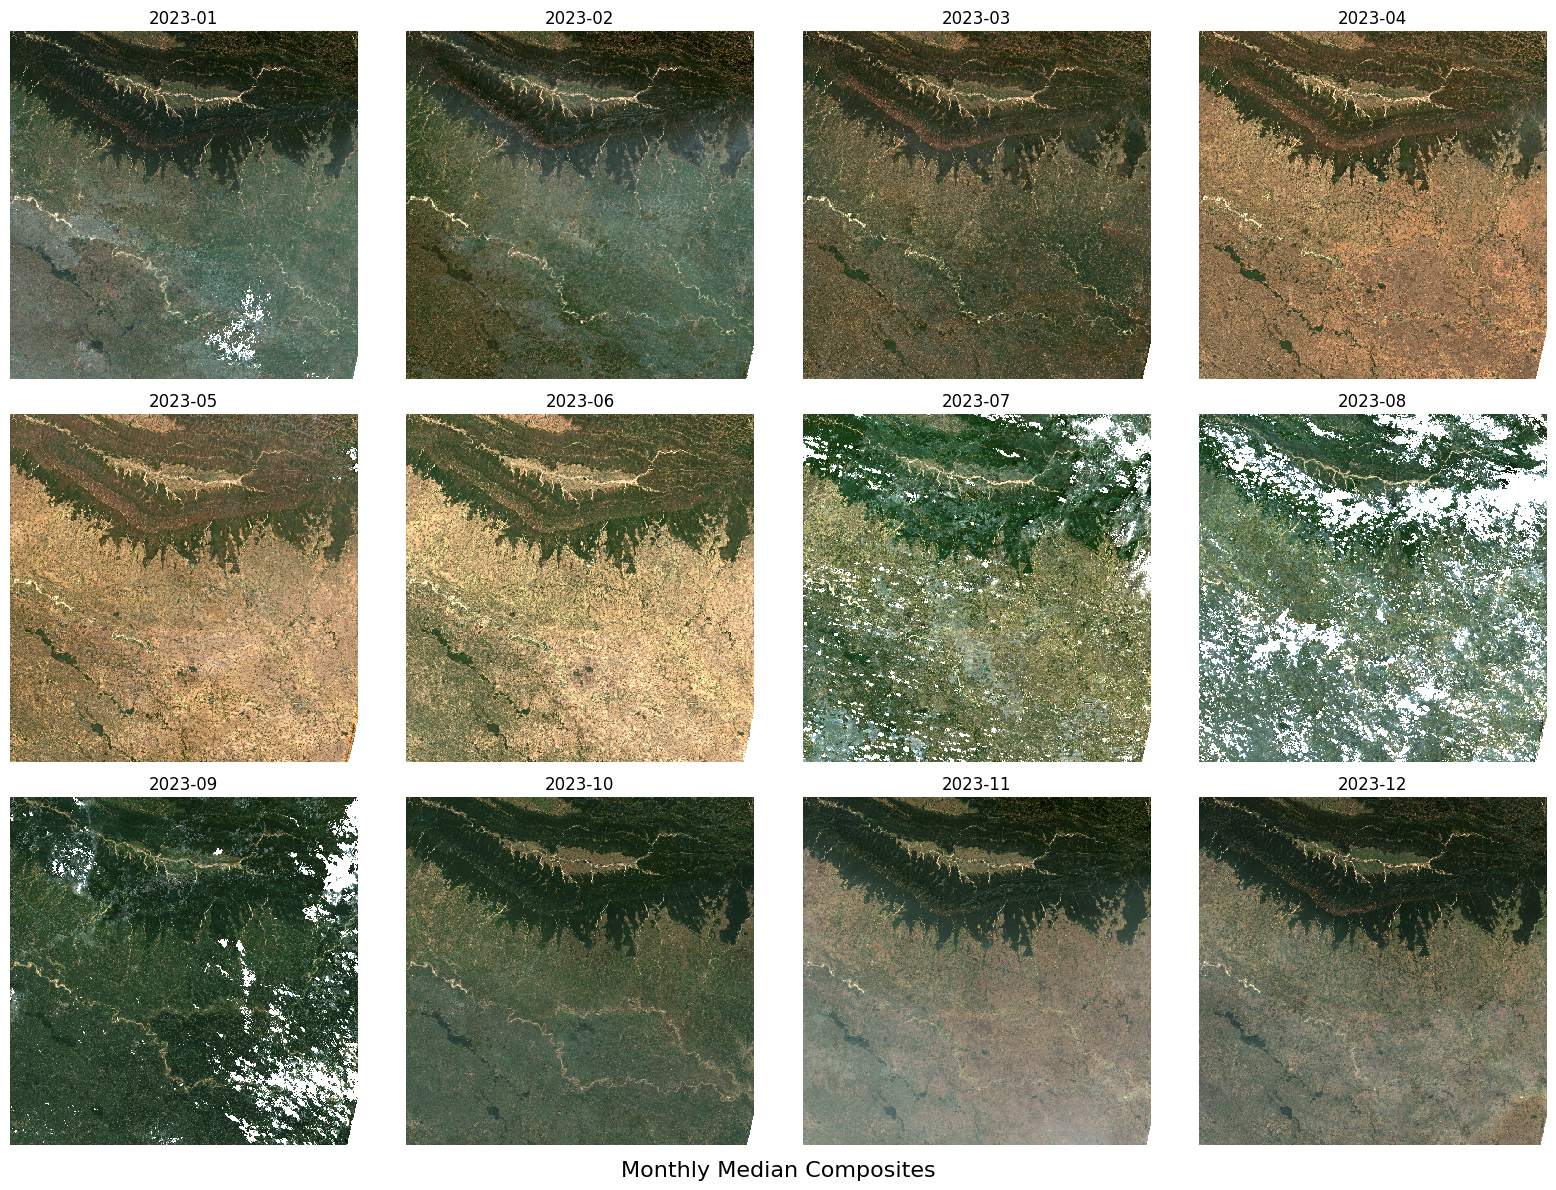

In [27]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i, ax in enumerate(axes.flat):
    scene = monthly.isel(month=i)
    date_str = f'{year}-{scene.month.item():02d}'

    rgb_da = scene[['red', 'green', 'blue']].to_array('band')
    rgb_da.plot.imshow(ax=ax, vmin=0, vmax=0.25)
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax.set_title(date_str)

    fig.canvas.draw()
    extent = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    output_filepath = os.path.join(output_folder, f'preview_{date_str}.png')
    fig.savefig(output_filepath, bbox_inches=extent)

plt.suptitle('Monthly Median Composites', fontsize=16, y=0)
plt.tight_layout()
plt.show()

Instead of monthly composites, we can create seasonal composites suitable for monitoring agriculture.

In [ ]:
ds_seasonal = ds.copy()
months = ds_seasonal.time.dt.month
seasons = xr.full_like(months, fill_value="none", dtype="U18") # Increased dtype to accommodate longer season names
seasons.name = 'season'
# Jan-March = Winter (Rabi) Crops
seasons[months.isin([1, 2, 3])] = 'rabi'
# April-June  = Summer Crops / Harvest
seasons[months.isin([4, 5, 6])] = 'summer'
# Monsoon (Kharif) Crops
seasons[months.isin([7, 8, 9, 10, 11, 12])] = 'kharif'
ds_seasonal.coords['season'] = seasons
ds_seasonal

Compute seasonal median composites.

In [ ]:
seasonal = ds_seasonal.groupby(['time.year', 'season']).median()
seasonal

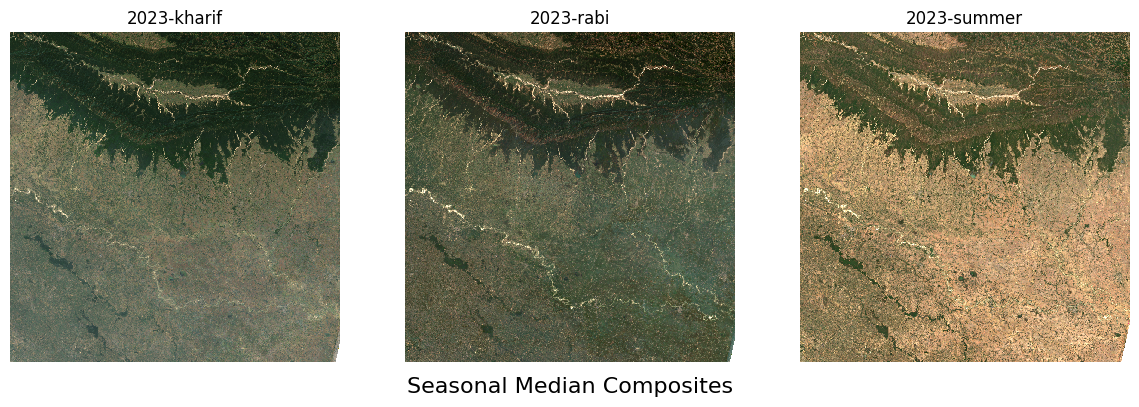

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, ax in enumerate(axes.flat):
    scene = seasonal.isel(season=i).squeeze()
    date_str = f'{year}-{scene.season.item()}'

    rgb_da = scene[['red', 'green', 'blue']].to_array('band')
    rgb_da.plot.imshow(ax=ax, vmin=0, vmax=0.25)
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax.set_title(date_str)

    fig.canvas.draw()
    extent = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    output_filepath = os.path.join(output_folder, f'preview_{date_str}.png')
    fig.savefig(output_filepath, bbox_inches=extent)

plt.suptitle('Seasonal Median Composites', fontsize=16, y=0)
plt.tight_layout()
plt.show()

#### Percentile Composites

A median composite takes the 50th percentile value from the image stack to create the final image. For very cloudy regions- where you expect most images to have clouds, the 50th percentile (median) value could still be cloudy. In such cases, you can use  [`xr_quantile`](https://github.com/opendatacube/odc-algo) from `odc-algo` to create composite with a custom percentile value to ensure a cloud-free observation.

Here we create a 10th, 25th, 50th and 75th percentile annual composites.

In [ ]:
percentiles = [0.1, 0.25, 0.5, 0.75]
annual_percentiles = xr_quantile(ds, percentiles, nodata=np.nan)

Preview all percentile composites.

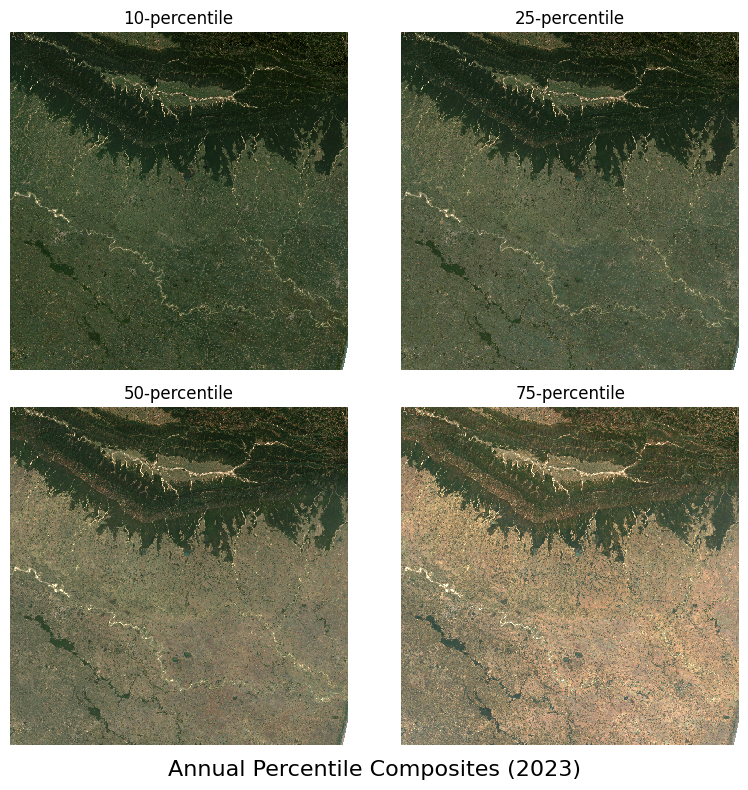

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

for p, ax in zip(percentiles, axes.flat):
    label = f'{int(p * 100)}-percentile'

    rgb_da = annual_percentiles.sel(quantile=p)[['red', 'green', 'blue']].to_array('band')
    rgb_da.plot.imshow(ax=ax, vmin=0, vmax=0.25)
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax.set_title(label)

    fig.canvas.draw()
    extent = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    output_filepath = os.path.join(output_folder, f'preview_annual_composite_{year}_{label}.png')
    fig.savefig(output_filepath, bbox_inches=extent)

plt.suptitle(f'Annual Percentile Composites ({year})', fontsize=16, y=0)
plt.tight_layout()
plt.show()

#### Geometric Median

The per-band `.median()` picks each band's median independently, so the output pixel can mix reflectance values from different acquisition dates that never actually occurred together in any single scene. Geometric Median calculates the multi-dimensional median cross all bands jointly, so the resulting pixel is spectrally consistent with the real observations. We use the [`xr_geomedian()`](https://github.com/opendatacube/odc-algo) from `odc-algo` to calculate geometric median. Learn more about the algorithm in the paper [High-Dimensional Pixel Composites From Earth Observation Time Series](https://ieeexplore.ieee.org/document/8004469).

In [ ]:
annual_median = ds.median(dim='time')
annual_geomedian = xr_geomedian(ds)

Preview the median and geomedian composites side-by-side.

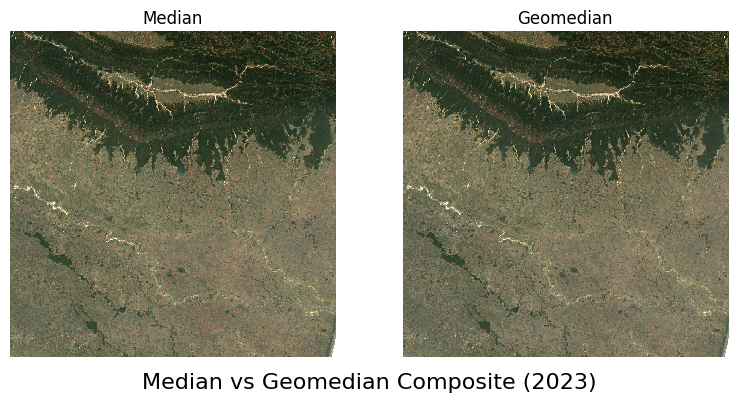

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for composite, label, ax in zip(
    [annual_median, annual_geomedian], ['Median', 'Geomedian'], axes
):
    rgb_da = composite[['red', 'green', 'blue']].to_array('band')
    rgb_da.plot.imshow(ax=ax, vmin=0, vmax=0.25)
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax.set_title(label)

plt.suptitle(f'Median vs Geomedian Composite ({year})', fontsize=16, y=0)
plt.tight_layout()
output_filepath = os.path.join(
    output_folder, f'preview_annual_composite_{year}_median_vs_geomedian.png')
fig.savefig(output_filepath, bbox_inches='tight')
plt.show()

Close the dask client. This presents multiple clients being instantiated when running different notebooks on the same machine. This is not required on Colab but a good practice when you are running it on a local machine. Uncomment and run to shutdown the dask cluster.

In [ ]:
#client.shutdown()